In [53]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import torch

from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
from sentence_transformers import util

In [54]:
with open("code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open("eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

print("Corpus size:", len(corpus))
print("Questions size:", len(questions))

Corpus size: 200
Questions size: 25


In [55]:
corpus_texts = [
    f"Функция {item['function_name']}: {item['description']}"
    for item in corpus
]

corpus_ids = [item["id"] for item in corpus]
corpus_categories = [item["category"] for item in corpus]

In [56]:
models = {
    "MiniLM": SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    "MPNet": SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"),
    "E5": SentenceTransformer("intfloat/multilingual-e5-base")
}

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9395.17it/s]


In [57]:
def encode_corpus(model_name, model, texts):
    if model_name == "E5":
        texts = ["passage: " + t for t in texts]
    return model.encode(texts, convert_to_tensor=True)


def encode_query(model_name, model, text):
    if model_name == "E5":
        text = "query: " + text
    return model.encode(text, convert_to_tensor=True)

In [58]:
embeddings = {}

for name, model in models.items():
    embeddings[name] = encode_corpus(name, model, corpus_texts)

print("Embeddings created")

Embeddings created


In [59]:
def search_top3(model_name, model, corpus_embs, question):
    q_emb = encode_query(model_name, model, question)
    scores = util.cos_sim(q_emb, corpus_embs)[0]
    scores_np = scores.cpu().numpy()
    top3_idx = np.argsort(scores_np)[::-1][:3]

    return top3_idx

In [60]:
results = []

for model_name, model in models.items():
    correct = 0
    for q in questions:
        top3 = search_top3(
            model_name,
            model,
            embeddings[model_name],
            q["query"]
        )

        # Приводим к строкам оба ID, чтобы избежать дурацких ошибок примитивов
        predicted_ids = [str(corpus_ids[i]) for i in top3]

        if str(q["correct_chunk_id"]) in predicted_ids:
            correct += 1

    precision = correct / len(questions)
    results.append({
        "Model": model_name,
        "Precision@3": precision
    })

df_results = pd.DataFrame(results)
df_results

,Model,Precision@3
0,MiniLM,0.80
1,MPNet,0.92
2,E5,1.00


In [61]:
best_model_name = df_results.sort_values(
    "Precision@3",
    ascending=False
).iloc[0]["Model"]

best_model_name

'E5'

In [62]:
best_embeddings = embeddings[best_model_name].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(best_embeddings)

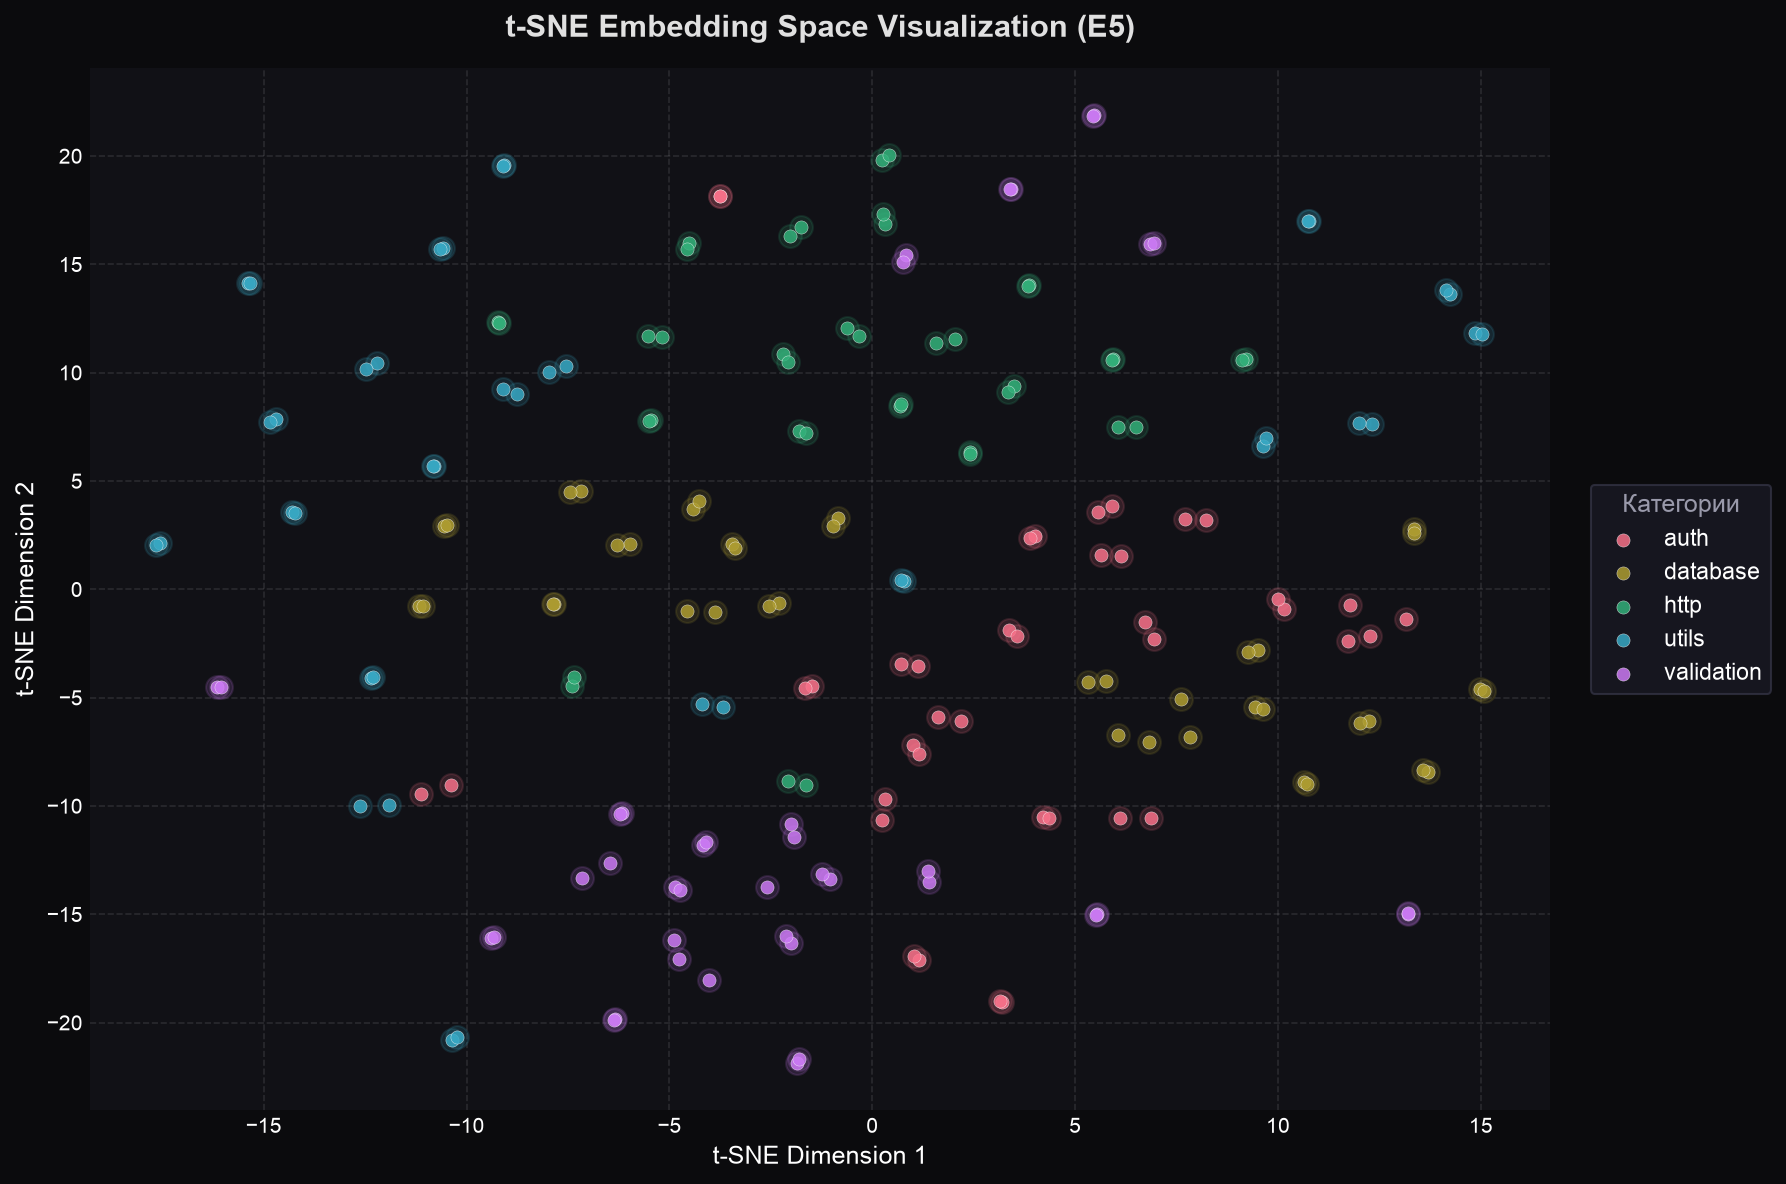

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

unique_categories = sorted(list(set(corpus_categories)))
colors = sns.color_palette("husl", len(unique_categories))

for i, category in enumerate(unique_categories):
    idxs = [idx for idx, c in enumerate(corpus_categories) if c == category]

    ax.scatter(
        coords[idxs, 0],
        coords[idxs, 1],
        alpha=0.15,
        s=120,
        color=colors[i]
    )

    ax.scatter(
        coords[idxs, 0],
        coords[idxs, 1],
        label=category,
        alpha=0.85,
        s=40,
        color=colors[i],
        edgecolors="white",
        linewidths=0.2
    )

ax.grid(True, linestyle="--", alpha=0.1, color="white")
ax.set_facecolor("#111116")
fig.patch.set_facecolor("#0b0b0d")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title(
    f"t-SNE Эмбеддинги\n Модель: {best_model_name} ",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#e0e0e0",
    fontname="sans-serif"
)

ax.set_title(
    f"t-SNE Embedding Space Visualization ({best_model_name})",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("t-SNE Dimension 1", fontsize=12)
ax.set_ylabel("t-SNE Dimension 2", fontsize=12)

legend = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=11,
    title="Категории",
    title_fontsize=12
)
legend.get_frame().set_facecolor("#1a1a24")
legend.get_frame().set_edgecolor("#333344")
legend.get_title().set_color("#9999aa")

ax.set_xticks(np.arange(-15, 16, 5))
ax.set_yticks(np.arange(-20, 21, 5))

ax.grid(True, linestyle="--", alpha=0.10)

plt.tight_layout()
plt.show()

In [68]:
metrics = []
mistakes = []

category_map = {str(item["id"]): item["category"] for item in corpus}

for name, model in models.items():

    corpus_vecs = embeddings[name]

    for lang_tag, lang_name in [("ru", "RU"), ("en", "EN")]:

        def is_russian(text):
            return len(re.findall(r"[а-яА-Я]", text)) > len(re.findall(r"[a-zA-Z]", text))

        if lang_tag == "ru":
            subset = [q for q in questions if is_russian(str(q["query"]))]
        else:
            subset = [q for q in questions if not is_russian(str(q["query"]))]

        if not subset:
            print(f"  - {lang_name}: нет данных")
            continue

        hits = 0

        for item in subset:
            q_emb = encode_query(name, model, item["query"])

            scores = util.cos_sim(q_emb, corpus_vecs)[0]
            top3_idx = torch.topk(scores, k=3).indices.tolist()

            predicted_ids = {str(corpus_ids[i]) for i in top3_idx}
            true_id = str(item["correct_chunk_id"])

            if true_id in predicted_ids:
                hits += 1
            else:
                mistakes.append({
                    "model": name,
                    "category": category_map.get(true_id, "unknown")
                })

        precision = hits / len(subset)
        metrics.append({
            "Модель": name,
            "Язык запроса": lang_name,
            "Precision@3": round(precision, 3)
        })

print("\n" + "="*50)
print("ИТОГОВЫЕ ТАБЛИЦЫ:")
print("="*50)

df_metrics = pd.DataFrame(metrics)
print("\n1. ТАБЛИЦА МУЛЬТИЯЗЫЧНОСТИ:")
display(df_metrics)

print("\n2. ТАБЛИЦА ОШИБОК ПО КАТЕГОРИЯМ:")
if mistakes:
    df_mistakes = pd.DataFrame(mistakes)
    df_mistakes_summary = (
        df_mistakes
        .groupby(["model", "category"])
        .size()
        .reset_index(name="Количество ошибок")
        .rename(columns={"model": "Модель", "category": "Категория"})
    )
    display(df_mistakes_summary)
else:
    print("Ошибок не обнаружено! Все модели отработали со 100% точностью.")


ИТОГОВЫЕ ТАБЛИЦЫ ДЛЯ ОТЧЕТА:

1. ТАБЛИЦА МУЛЬТИЯЗЫЧНОСТИ:


,Модель,Язык запроса,Precision@3
0,MiniLM,RU,0.733
1,MiniLM,EN,0.900
2,MPNet,RU,0.933
3,MPNet,EN,0.900
4,E5,RU,1.000
5,E5,EN,1.000



2. ТАБЛИЦА ОШИБОК ПО КАТЕГОРИЯМ:


,Модель,Категория,Количество ошибок
0,MPNet,auth,1
1,MPNet,utils,1
2,MiniLM,auth,1
3,MiniLM,database,1
4,MiniLM,http,1
5,MiniLM,utils,1
6,MiniLM,validation,1
